<a href="https://colab.research.google.com/github/affled/LED1703/blob/main/request3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
!pip install numpy numpy


In [147]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")


In [148]:
df = pd.read_excel('/content/dar23.xlsx', header = 1).drop(columns=['Unnamed: 0', 'Unnamed: 13', 'Unnamed: 15'])
df.head()

,В/П,№ рейса,Код АП,Маршрут,Борт,Время рейса план,Actual data time,ONB and OFB,Компоновка,Вместимость,...,Кл.1,Кл.2,Кл.3,"МВМ, тонн",Тип ВС,АВК,Направление,Катег,Baggage Weight,Spot Number
0,В,DP 204,VKO,ВНУКОВО,RA73232,2024-12-31 19:30:00,2025-01-01 00:01:00,2024-12-31 23:53:00,Y189,189.0,...,0.0,0.0,115.0,75.296,73H,1.0,Domestic,J,143.0,106A
1,В,FZ 992,DXB,ДУБАЙ,A6FMJ,2025-01-01 00:25:00,2025-01-01 01:03:00,2025-01-01 00:50:00,174,166.0,...,0.0,0.0,132.0,82.190,7M8,1.0,International,J,1396.0,104B
2,В,2S 204,AYT,АНТАЛЬЯ,TCGRA,2025-01-01 01:30:00,2025-01-01 02:05:00,2025-01-01 01:46:00,Y345,312.0,...,0.0,0.0,342.0,233.000,332,1.0,International,J,3881.0,105
3,П,JU 124,BEG,БЕЛГРАД,YUAPN,2025-01-01 04:05:00,2025-01-01 04:06:00,2025-01-01 04:11:00,12J126Y,144.0,...,0.0,0.0,66.0,70.000,319,1.0,International,J,1159.0,104B
4,В,SU 734,SSH,ШАРМ-ЭЛЬ-ШЕЙХ,73785,2025-01-01 04:00:00,2025-01-01 04:19:00,2025-01-01 04:04:00,C28Y268,296.0,...,0.0,23.0,260.0,230.000,333,1.0,International,J,3243.0,103


In [151]:
df = df.dropna()
df.isna().sum().sum()

np.int64(0)

In [154]:
import matplotlib.pyplot as plt


In [243]:
import ipywidgets as widgets

Доступные столбцы для выбора:
0: Baggage Weight
1: Вместимость
2: Обслужено пассажиров
3: МВМ, тонн
4: Кл.3
Введите номер столбца для отображения и нажмите Enter: 2


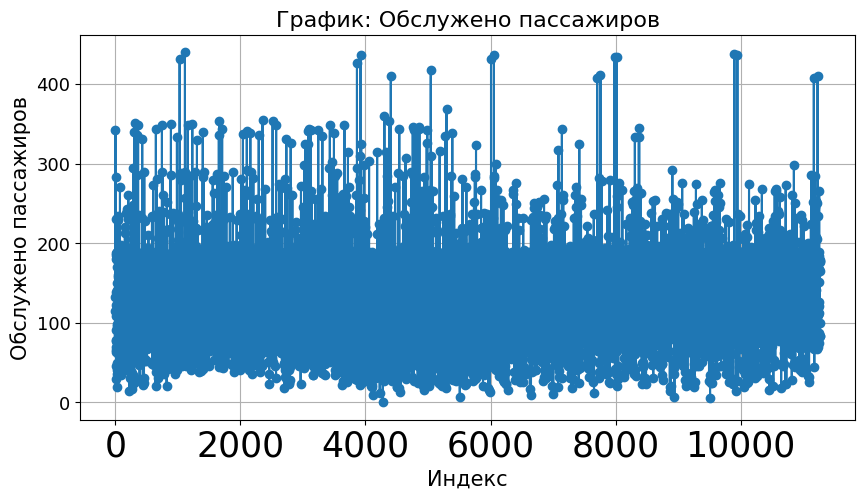

In [289]:
#не разобрался, как корректно вывести все графики сразу т.к. выпадала ошибка AttributeError: 'Axes' object has no attribute 'plt', попросил gpt помочь сделать со списком данные. так локаниченее
columns = ['Baggage Weight', 'Вместимость', 'Обслужено пассажиров','МВМ, тонн',"Кл.3"]


# Отображение списка столбцов с индексами
print("Доступные столбцы для выбора:")
for idx, col in enumerate(columns):
    print(f"{idx}: {col}")

# Запрос выбора пользователя
choice = int(input("Введите номер столбца для отображения и нажмите Enter: "))

# Проверка корректности ввода
if 0 <= choice < len(columns):
    selected_column = columns[choice]
    plt.figure(figsize=(10, 5))
    plt.plot(df[selected_column], marker='o')
    plt.title(f'График: {selected_column}')
    plt.xlabel('Индекс')
    plt.ylabel(selected_column)
    plt.grid(True)
    plt.show()
else:
    print("У нас в списке нет таких позиций")



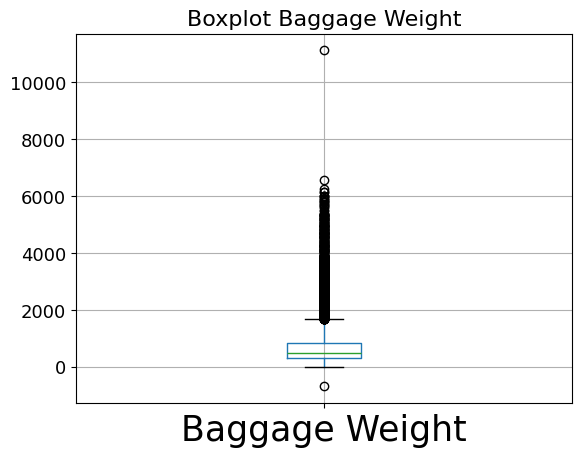

In [261]:
df.boxplot(column='Baggage Weight', grid=True)
plt.title('Boxplot Baggage Weight')
plt.show()

Text(0.5, 1.0, 'Boxplot Baggage Weight')

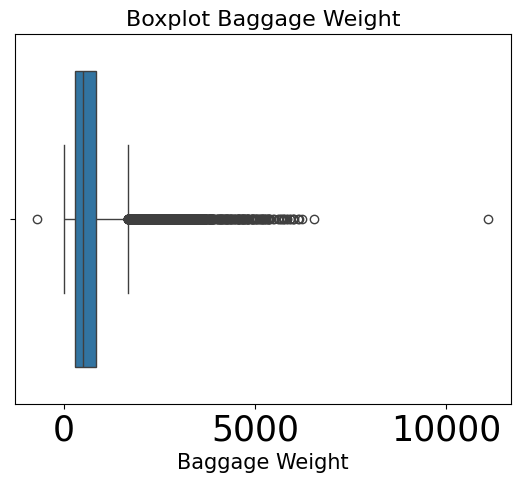

In [285]:
sns.boxplot(x=df['Baggage Weight']);
plt.title('Boxplot Baggage Weight')

Медиана расположена ниже центральной линии, что может говорить нам о большом количестве рейсов с низкой загрузкой.
Есть значение ниже нуля, что говорит о наличии ошибки в данных.
Также присутсвует одиночный выброс, возможно рейс был максимально загружен.

Text(0.5, 1.0, 'Вылет и Прилет')

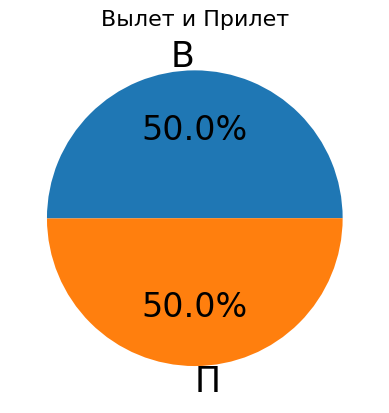

In [286]:
data = df['В/П'].value_counts(normalize=True)

fig, ax = plt.subplots()
ax.pie(data, labels=data.index, autopct='%1.1f%%');
plt.title('Вылет и Прилет')

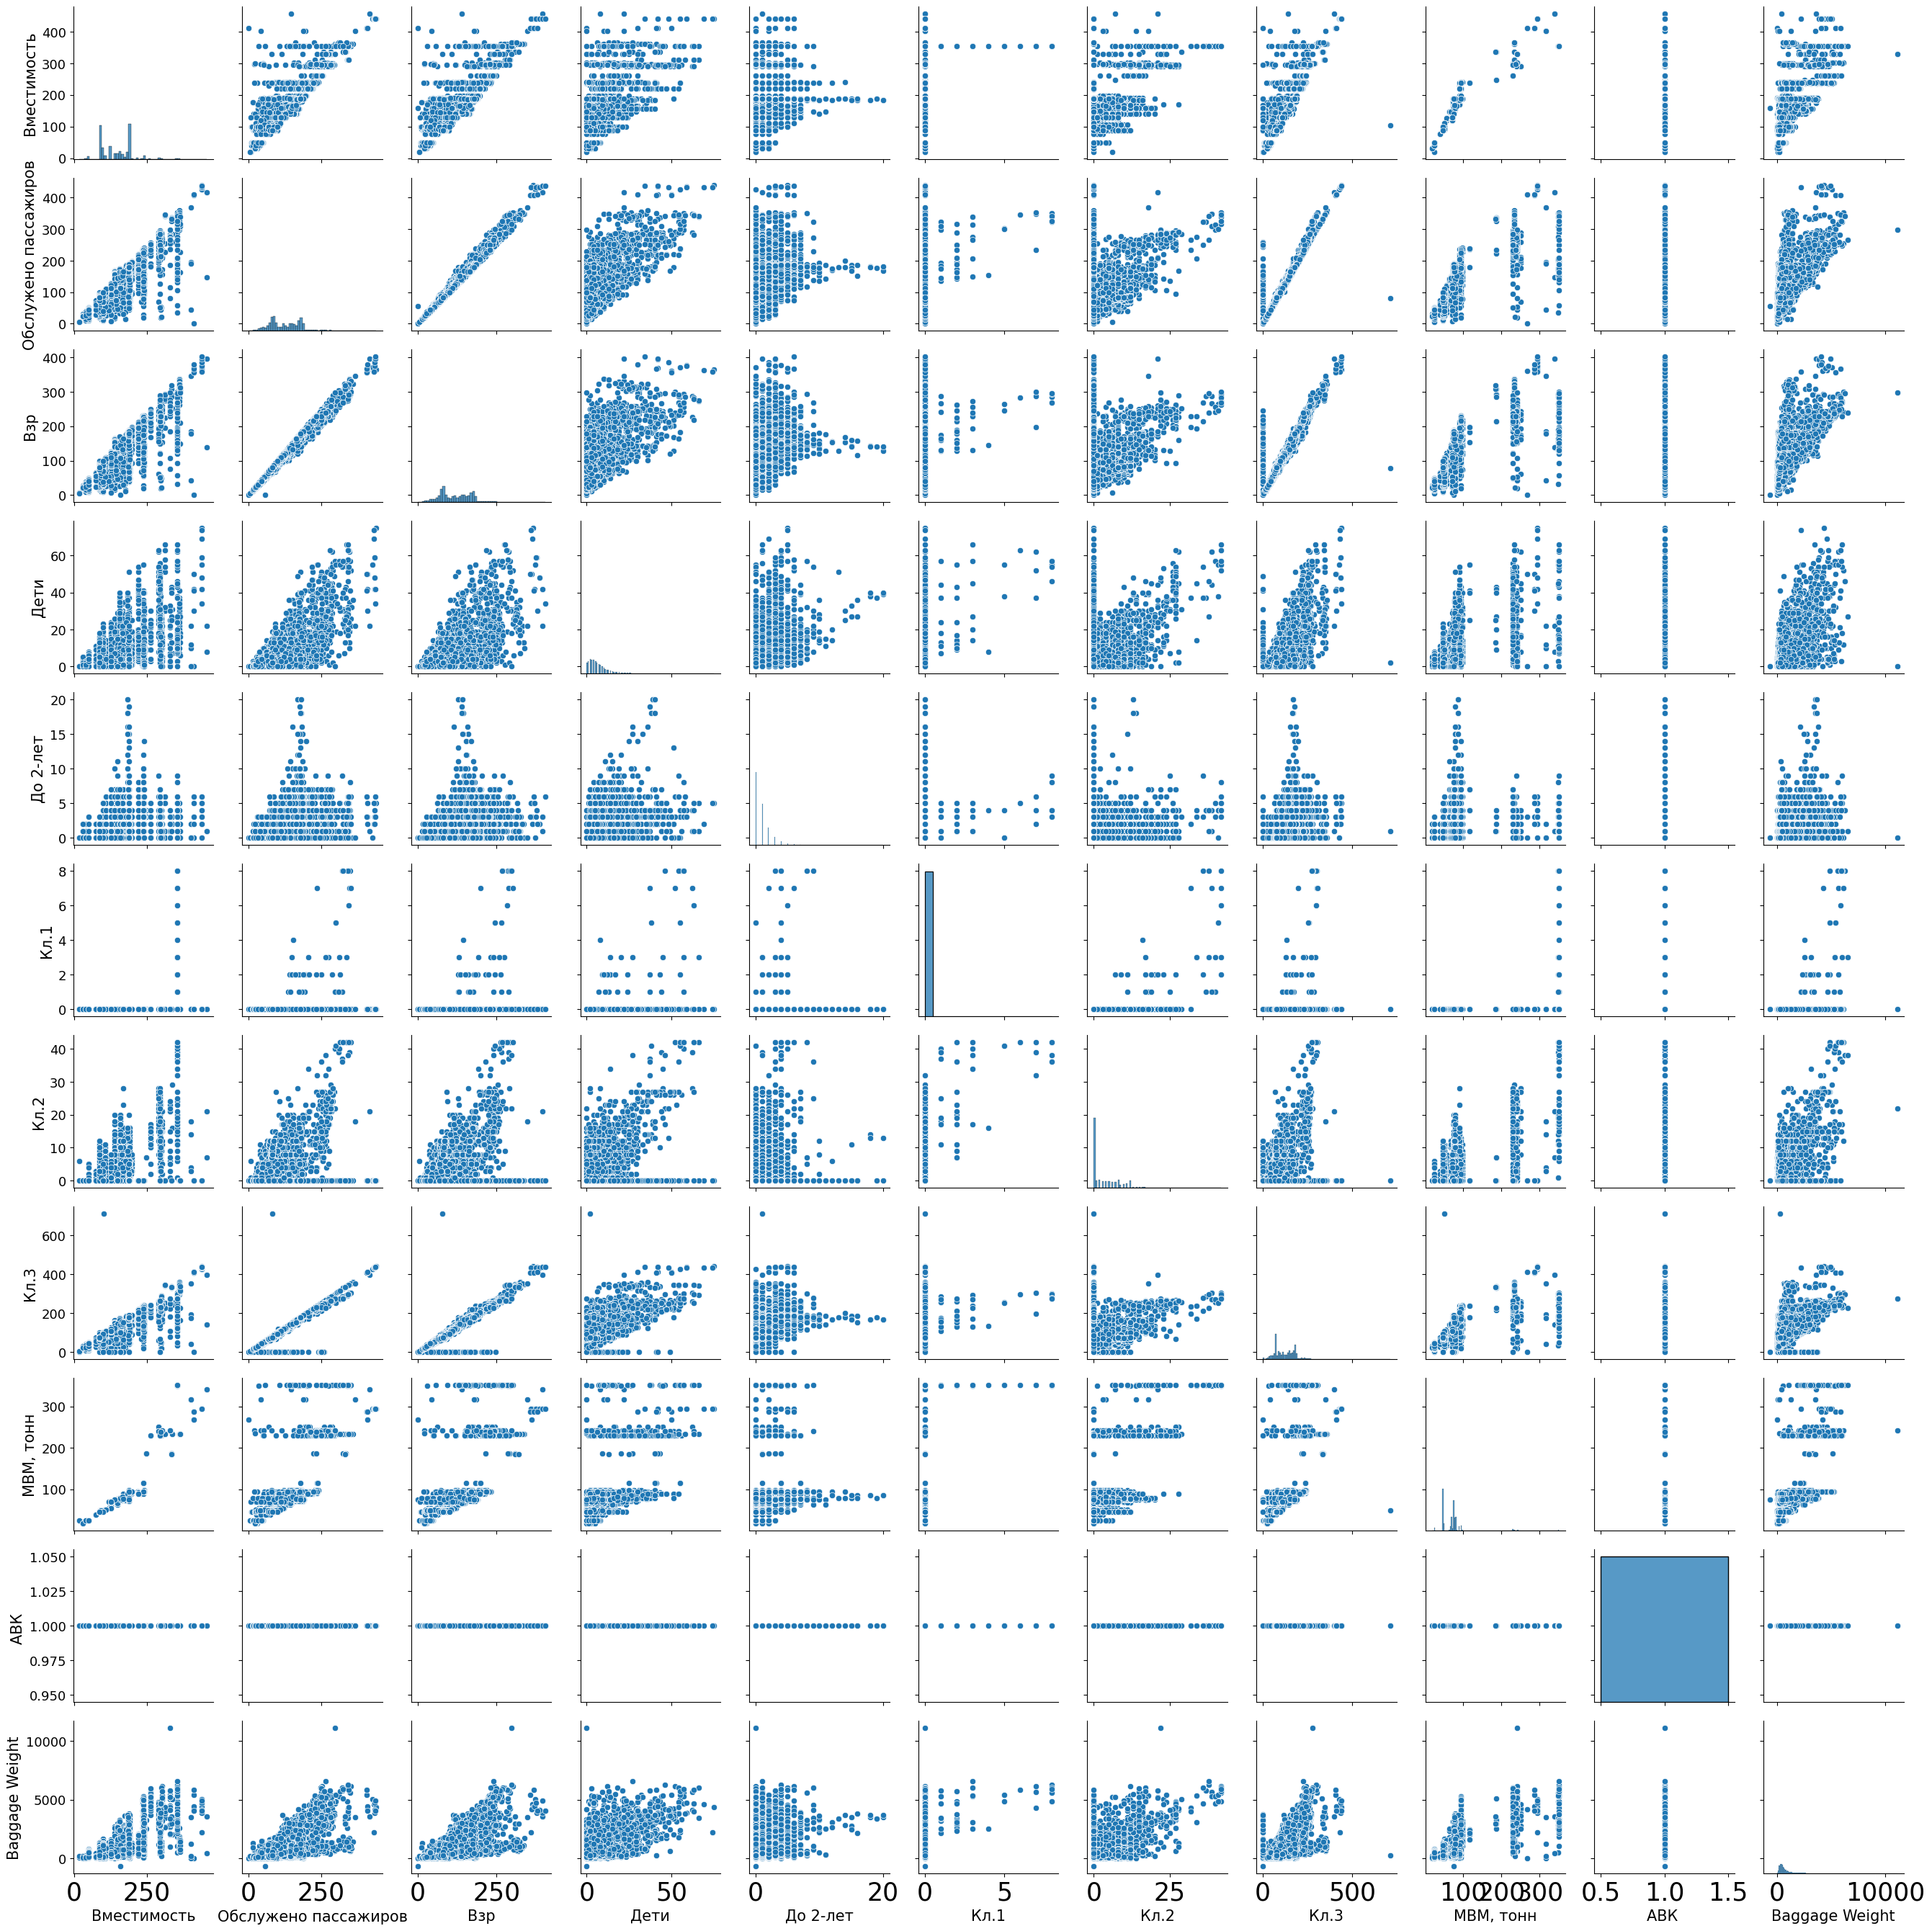

In [290]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
sns.pairplot(df[numeric_cols])
plt.show()

In [271]:
import plotly.express as px
import pandas as pd

In [281]:

df = pd.read_excel('/content/dar23.xlsx', header = 1).drop(columns=['Unnamed: 0', 'Unnamed: 13', 'Unnamed: 15'])
df.head()

,В/П,№ рейса,Код АП,Маршрут,Борт,Время рейса план,Actual data time,ONB and OFB,Компоновка,Вместимость,...,Кл.1,Кл.2,Кл.3,"МВМ, тонн",Тип ВС,АВК,Направление,Катег,Baggage Weight,Spot Number
0,В,DP 204,VKO,ВНУКОВО,RA73232,2024-12-31 19:30:00,2025-01-01 00:01:00,2024-12-31 23:53:00,Y189,189.0,...,0.0,0.0,115.0,75.296,73H,1.0,Domestic,J,143.0,106A
1,В,FZ 992,DXB,ДУБАЙ,A6FMJ,2025-01-01 00:25:00,2025-01-01 01:03:00,2025-01-01 00:50:00,174,166.0,...,0.0,0.0,132.0,82.190,7M8,1.0,International,J,1396.0,104B
2,В,2S 204,AYT,АНТАЛЬЯ,TCGRA,2025-01-01 01:30:00,2025-01-01 02:05:00,2025-01-01 01:46:00,Y345,312.0,...,0.0,0.0,342.0,233.000,332,1.0,International,J,3881.0,105
3,П,JU 124,BEG,БЕЛГРАД,YUAPN,2025-01-01 04:05:00,2025-01-01 04:06:00,2025-01-01 04:11:00,12J126Y,144.0,...,0.0,0.0,66.0,70.000,319,1.0,International,J,1159.0,104B
4,В,SU 734,SSH,ШАРМ-ЭЛЬ-ШЕЙХ,73785,2025-01-01 04:00:00,2025-01-01 04:19:00,2025-01-01 04:04:00,C28Y268,296.0,...,0.0,23.0,260.0,230.000,333,1.0,International,J,3243.0,103


In [283]:
df = df.dropna()

In [304]:
fig = px.sunburst(df, path=['В/П', 'Направление'])
fig.update_layout(title="График В/П по направлениям")
fig.show()

